### 1. Load & Setup

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score  
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
import shap
import time
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# one shared style setup
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

In [3]:
model_colours = {
    'Random Forest': '#1f77b4',  # blue
    'XGBoost': '#9467bd',  # purple
    'Decision Tree': '#e377c2',  # pink
    'Logistic Regression': '#2ca02c',  # green  
    'Neural Network': '#d62728' #red

}

#### 1.1 Load Fused Dataset

In [ ]:
base = os.path.join("..", "data", "processed")
fused_path = os.path.join(base, "fused_clean.csv")
fused_df = pd.read_csv(fused_path, 
                       dtype = {'FIPS': str, 'ORI7': str},
                       low_memory = False)
print(f"Shape of Fused Dataset: {fused_df.shape}")
print(f"\nColumns in Fused Dataset: {list(fused_df.columns)}")
print(f"\nFIPS Sample: {fused_df['FIPS'].head(5).tolist()}")

Shape of Fused Dataset: (878210, 37)

Columns in Fused Dataset: ['ID', 'CNTYFIPS', 'Ori', 'State', 'Agency', 'Agentype', 'Year', 'Month', 'Incident', 'VicAge', 'VicSex', 'VicRace', 'Weapon', 'Circumstance', 'VicCount', 'OffCount', 'SOLVED', 'VicAgeBand', 'agency_year_month', 'Monthly_Overlap', 'NearLemas', 'FIPS', 'ORI7', 'STATE', 'FTSWORN', 'PTSWORN', 'TOTFTEMP', 'OPBUDGET', 'DET_SWN', 'PERS_TRN_ACAD', 'PERS_TRN_INSVC', 'PERS_EDU_MIN', '_lemas_merge', 'NAME', 'PovertyRate', 'UnemploymentRate', '_acs_merge']

FIPS Sample: ['02020', '02020', '02020', '02020', '02020']


#### 1.2 Sanity Check

In [5]:
print("Data Types:")
print(fused_df.dtypes)
print(f"ORI7 Sample: {fused_df['ORI7'].head(5).tolist()}")
print(f"Duplicate IDs: {fused_df['ID'].duplicated().sum()}")

Data Types:
ID                       str
CNTYFIPS                 str
Ori                      str
State                    str
Agency                   str
Agentype                 str
Year                   int64
Month                    str
Incident               int64
VicAge                 int64
VicSex                   str
VicRace                  str
Weapon                   str
Circumstance             str
VicCount               int64
OffCount               int64
SOLVED                 int64
VicAgeBand               str
agency_year_month        str
Monthly_Overlap        int64
NearLemas              int64
FIPS                     str
ORI7                     str
STATE                    str
FTSWORN              float64
PTSWORN              float64
TOTFTEMP             float64
OPBUDGET             float64
DET_SWN              float64
PERS_TRN_ACAD        float64
PERS_TRN_INSVC       float64
PERS_EDU_MIN         float64
_lemas_merge             str
NAME                     str
Po

### 2. Feature Selection 

#### 2.1 Categorise Columns

The columns will be divided into five groups:
- Identifiers/Bookkeeping Variables
- Target Variable
- Analysis Flag Variables 
- Case Level Features from MAP
- Additional LEMAS/ACS Features 

This separation is used to create the case-level-only and fused feature sets.


In [6]:
id_cols = ['ID', 'Incident', 'CNTYFIPS', 'Ori', 'FIPS',
           'Agency', 'ORI7', 'STATE', 'NAME', 
           '_lemas_merge', '_acs_merge', 'agency_year_month']

target_col = 'SOLVED'

analysis_flag_cols = ['NearLemas', 'VicAgeBand']

case_level_cols = ['State', 'Agentype', 'Year', 'Month', 'VicAge', 
                   'VicSex', 'VicRace', 'Weapon', 'Circumstance',
                   'VicCount', 'OffCount', 'Monthly_Overlap']

lemas_acs_cols = ['FTSWORN', 'PTSWORN', 'TOTFTEMP', 'OPBUDGET', 
                  'DET_SWN', 'PERS_TRN_ACAD', 'PERS_TRN_INSVC', 
                  'PERS_EDU_MIN', 'PovertyRate', 'UnemploymentRate']

# check every column is accounted for exactly once
all_grouped = (
    id_cols
    + [target_col]
    + analysis_flag_cols
    + case_level_cols
    + lemas_acs_cols
)
missing = set(fused_df.columns) - set(all_grouped)
extra = set(all_grouped) - set(fused_df.columns)
print(f"\nMissing Columns: {missing}")
print(f"\nExtra Columns: {extra}")


Missing Columns: set()

Extra Columns: set()


#### 2.2 Define Feature Sets 

In [7]:
case_level_features = case_level_cols
fused_features = case_level_features + lemas_acs_cols

print(f"Case Level Features ({len(case_level_features)}): {case_level_features}")
print(f"Fused Features ({len(fused_features)}): {fused_features}")

Case Level Features (12): ['State', 'Agentype', 'Year', 'Month', 'VicAge', 'VicSex', 'VicRace', 'Weapon', 'Circumstance', 'VicCount', 'OffCount', 'Monthly_Overlap']
Fused Features (22): ['State', 'Agentype', 'Year', 'Month', 'VicAge', 'VicSex', 'VicRace', 'Weapon', 'Circumstance', 'VicCount', 'OffCount', 'Monthly_Overlap', 'FTSWORN', 'PTSWORN', 'TOTFTEMP', 'OPBUDGET', 'DET_SWN', 'PERS_TRN_ACAD', 'PERS_TRN_INSVC', 'PERS_EDU_MIN', 'PovertyRate', 'UnemploymentRate']


### 3. Train/Test Split

The data is split into 10 independent training and test sets before fitting the imputer, so the imputer is fitted using training data only. Repeating the split 10 times, rather than using a single split, tests whether the results are robust to different random splits of the data.

For each split, the case-level and fused feature sets are derived from the same `fused_df` and use the same training and test rows, ensuring that the only difference between the two feature sets is the features themselves.

The data is stratified by the target variable, so that the proportion of solved and unsolved cases is the same in the training and test sets.

In [8]:
n_splits = 10
split_seeds = range(n_splits)  # different random seeds for each split

splits = []
for seed in split_seeds:
    train_idx, test_idx = train_test_split(
        fused_df.index,
        test_size = 0.2,
        stratify = fused_df['SOLVED'],
        random_state = seed
    )
    splits.append((train_idx, test_idx))

print(f"Number of Splits: {len(splits)}")
print(f"Training Set Size: {len(splits[0][0])}, Test Set Size: {len(splits[0][1])}")

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"Split {i}: "
          f"Train Solved Rate = {fused_df.loc[train_idx, 'SOLVED'].mean():.4f}, "
          f"Test Solved Rate = {fused_df.loc[test_idx, 'SOLVED'].mean():.4f}")

Number of Splits: 10
Training Set Size: 702568, Test Set Size: 175642
Split 0: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 1: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 2: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 3: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 4: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 5: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 6: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 7: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 8: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060
Split 9: Train Solved Rate = 0.7060, Test Solved Rate = 0.7060


### 4. Missing Data Handling

#### 4.1 Missing Data Flags

Missing-data flags are created to see whether values are present or missing. 

In [9]:
lemas_only_cols = ['FTSWORN', 'PTSWORN', 'TOTFTEMP', 'OPBUDGET',
                   'DET_SWN', 'PERS_TRN_ACAD', 'PERS_TRN_INSVC', 'PERS_EDU_MIN']

acs_only_cols = ['PovertyRate', 'UnemploymentRate']

assert set(lemas_only_cols + acs_only_cols) == set(lemas_acs_cols)
print("lemas_only_cols and acs_only_cols correctly partition lemas_acs_cols.")


lemas_only_cols and acs_only_cols correctly partition lemas_acs_cols.


In [10]:
# lemas missing = unmatched agencies + matching agencies with missing values
fused_df['LEMAS_Missing'] = fused_df[lemas_only_cols].isnull().any(axis = 1).astype(int)
print(f"LEMAS_Missing: {fused_df['LEMAS_Missing'].mean():.2%} of rows")

# acs missing = unmatched agencies (no internal missing values)
fused_df['ACS_Missing'] = fused_df[acs_only_cols].isnull().any(axis = 1).astype(int)
print(f"ACS_Missing: {fused_df['ACS_Missing'].mean():.2%} of rows")

LEMAS_Missing: 27.73% of rows
ACS_Missing: 0.73% of rows


In [11]:
# check agentype distribution in first split
print(fused_df.loc[splits[0][0], 'Agentype'].value_counts())

Agentype
Municipal police      547221
Sheriff               116318
County police          20305
Primary state LE       16474
Special police          1325
Tribal                   454
Regional police          292
Primary federal LE       179
Name: count, dtype: int64


#### 4.2 Imputation


For each train/test split, LEMAS variables are imputed using the median within `Agentype`, calculated from the training set only. Where an agency type has no available training median, the overall training-set median is used. ACS variables are imputed using the overall training-set median. This prevents information from the test set from influencing preprocessing.

In [12]:
train_group_medians = fused_df.loc[splits[0][0]].groupby('Agentype')[lemas_only_cols].median()

train_global_medians_lemas = fused_df.loc[splits[0][0], lemas_only_cols].median()

train_group_medians = train_group_medians.fillna(train_global_medians_lemas)

print("LEMAS Medians by Agency Type (After Fallback):\n")
print(train_group_medians)

LEMAS Medians by Agency Type (After Fallback):

                    FTSWORN  PTSWORN  TOTFTEMP     OPBUDGET  DET_SWN  \
Agentype                                                               
County police        1541.0      0.0    1787.0  236088678.0    111.0   
Municipal police     1547.0      0.0    1841.0  266173000.0    175.0   
Primary federal LE   1197.0      0.0    1792.0  236088678.0    135.0   
Primary state LE      682.0      0.0     884.0  167187200.0     69.0   
Regional police        11.0      0.0      11.0    1342885.0      1.0   
Sheriff               354.0      3.0     717.0   94398387.0     29.0   
Special police        211.0      0.0     290.0   61558342.0     28.0   
Tribal               1197.0      0.0    1792.0  236088678.0    135.0   

                    PERS_TRN_ACAD  PERS_TRN_INSVC  PERS_EDU_MIN  
Agentype                                                         
County police              1174.0            40.0           4.0  
Municipal police            920.0

In [13]:
train_global_medians_acs = fused_df.loc[splits[0][0], acs_only_cols].median()
print("ACS Global Medians:")
print(train_global_medians_acs)

ACS Global Medians:
PovertyRate         14.100000
UnemploymentRate     5.846893
dtype: float64


In [14]:
fused_df_imputed_split0 = fused_df.copy()

for col in lemas_only_cols:
    group_map = train_group_medians[col]
    fill_values = fused_df_imputed_split0['Agentype'].map(group_map)
    fused_df_imputed_split0[col] = fused_df_imputed_split0[col].fillna(fill_values)

for col in acs_only_cols:
    fused_df_imputed_split0[col] = fused_df_imputed_split0[col].fillna(train_global_medians_acs[col])

# check that there are no missing values in the imputed dataset
print("Missing Values in Imputed Dataset:")
print(fused_df_imputed_split0[lemas_only_cols + acs_only_cols].isnull().sum())

Missing Values in Imputed Dataset:
FTSWORN             0
PTSWORN             0
TOTFTEMP            0
OPBUDGET            0
DET_SWN             0
PERS_TRN_ACAD       0
PERS_TRN_INSVC      0
PERS_EDU_MIN        0
PovertyRate         0
UnemploymentRate    0
dtype: int64


#### 4.3 Reusable Pipeline

The imputation process is implemented as a reusable pipeline that can be applied to any train/test split. 

In [15]:
def impute_split(train_idx, fused_df):
    df = fused_df.copy()

    # imputation
    train_group_medians = df.loc[train_idx].groupby('Agentype')[lemas_only_cols].median()
    train_global_medians_lemas = df.loc[train_idx, lemas_only_cols].median()
    train_group_medians = train_group_medians.fillna(train_global_medians_lemas)
    train_global_medians_acs = df.loc[train_idx, acs_only_cols].median()

    for col in lemas_only_cols:
        df[col] = df[col].fillna(df['Agentype'].map(train_group_medians[col]))
    for col in acs_only_cols:
        df[col] = df[col].fillna(train_global_medians_acs[col])

    return df


### 5. Encoding and Scaling

#### 5.1 Categorical Features

Categorical variables are one-hot encoded using `sklearn`'s `OneHotEncoder`. The encoder is fitted on the training data only and then applied to both the training and test sets. `handle_unknown = 'ignore'` allows categories present only in the test set to be handled without errors.

The encoded categorical variables are combined with the numeric variables to create the case-level and fused feature matrices.

In [16]:
# check number of unique categories in each categorical column
categorical_cols = ['State', 'Agentype', 'Month', 'VicSex', 
                    'VicRace', 'Weapon', 'Circumstance']

print("Number of Categories in Each Column:")
for col in categorical_cols:
    print(f"{col}: {fused_df[col].nunique()}")

Number of Categories in Each Column:
State: 51
Agentype: 8
Month: 12
VicSex: 3
VicRace: 6
Weapon: 18
Circumstance: 28


In [17]:
def encode_and_scale_split(df, train_idx, test_idx):

    # define categorical and numeric columns
    categorical_cols = [
        'State', 'Agentype', 'Month', 'VicSex', 
        'VicRace', 'Weapon', 'Circumstance'
    ]

    numeric_cols = (
        ['Year', 'VicAge', 'VicCount', 'OffCount', 'Monthly_Overlap']
        + lemas_only_cols
        + acs_only_cols
    )

    # fit the encoder on the training data only
    encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
    encoder.fit(df.loc[train_idx, categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)

    # transform all rows using the fitted encoder
    encoded_array = encoder.transform(df[categorical_cols])

    encoded_df = pd.DataFrame(
        encoded_array,
        columns = encoded_cols,
        index = df.index
    )

    # combine numeric and encoded categorical features
    X_full = pd.concat([df[numeric_cols], encoded_df], axis = 1)

    # create case-level and fused feature sets
    case_level_X_cols = [
        c for c in X_full.columns
        if c not in (lemas_only_cols + acs_only_cols)
    ]

    X_case = X_full[case_level_X_cols]
    X_fused = X_full

    # split both feature sets into training and test sets
    X_case_train = X_case.loc[train_idx]
    X_case_test = X_case.loc[test_idx]

    X_fused_train = X_fused.loc[train_idx]
    X_fused_test = X_fused.loc[test_idx]

    # split the target variable using the same indices
    y_train = df.loc[train_idx, 'SOLVED']
    y_test = df.loc[test_idx, 'SOLVED']

    # fit scalers on the training data only
    scaler_case = StandardScaler()
    case_scale_cols = [c for c in numeric_cols if c in X_case_train.columns]
    scaler_case.fit(X_case_train[case_scale_cols])

    scaler_fused = StandardScaler()
    scaler_fused.fit(X_fused_train[numeric_cols])

    # transform both training and test sets using the fitted scalers
    X_case_train_scaled = X_case_train.copy()
    X_case_test_scaled = X_case_test.copy()

    X_case_train_scaled[case_scale_cols] = scaler_case.transform(
        X_case_train[case_scale_cols]
    )
    
    X_case_test_scaled[case_scale_cols] = scaler_case.transform(
        X_case_test[case_scale_cols]
    )

    X_fused_train_scaled = X_fused_train.copy()
    X_fused_test_scaled = X_fused_test.copy()

    X_fused_train_scaled[numeric_cols] = scaler_fused.transform(
        X_fused_train[numeric_cols]
    )

    X_fused_test_scaled[numeric_cols] = scaler_fused.transform(
        X_fused_test[numeric_cols]
    )

    # return all datasets and targets
    return {
        'X_case_train': X_case_train,
        'X_case_test': X_case_test,
        'X_fused_train': X_fused_train,
        'X_fused_test': X_fused_test,
        'X_case_train_scaled': X_case_train_scaled,
        'X_case_test_scaled': X_case_test_scaled,
        'X_fused_train_scaled': X_fused_train_scaled,
        'X_fused_test_scaled': X_fused_test_scaled,
        'y_train': y_train,
        'y_test': y_test
    }


In [18]:
imputed_df = impute_split(splits[0][0], fused_df)
result = encode_and_scale_split(imputed_df, splits[0][0], splits[0][1])
print(f"X_case_train shape: {result['X_case_train'].shape}")
print(f"X_case_test shape: {result['X_case_test'].shape}")
print(f"X_fused_train shape: {result['X_fused_train'].shape}")
print(f"X_fused_test shape: {result['X_fused_test'].shape}")

X_case_train shape: (702568, 131)
X_case_test shape: (175642, 131)
X_fused_train shape: (702568, 141)
X_fused_test shape: (175642, 141)


### 6. Class Imbalance Handling

#### 6.1 Check Class Balance

The training set is checked for class imbalance before calculating class weights.

In [19]:
# count of each class in the training set
class_counts = result['y_train'].value_counts()
print(f"Class Counts in Training Set:\n{class_counts}")
print(f"\nClass Balance (Train): {result['y_train'].mean():.2%} Solved, {1 - result['y_train'].mean():.2%} Unsolved")

Class Counts in Training Set:
SOLVED
1    495989
0    206579
Name: count, dtype: int64

Class Balance (Train): 70.60% Solved, 29.40% Unsolved


#### 6.2 Compute Class Weights

Class weights are calculated from the training data only using `compute_class_weight`. The higher weight assigned to unsolved cases gives the models greater emphasis on the minority class.

For XGBoost, the equivalent `scale_pos_weight` is calculated as the ratio of unsolved to solved cases.

In [20]:
# balanced weight = n_samples / (n_classes * n_samples_per_class)
# positive class = 1 (solved), negative class = 0 (unsolved)

def compute_class_weights(y_train):
    class_weights = compute_class_weight(
        class_weight = 'balanced',
        classes = np.array([0, 1]), 
        y = y_train
    )
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # for xgboost

    return class_weight_dict, scale_pos_weight

class_weight_dict, scale_pos_weight = compute_class_weights(result['y_train'])
print(f"Class Weights: {class_weight_dict}")
print(f"Scale Pos Weight: {scale_pos_weight:.4f} (Negative Class / Positive Class)")

Class Weights: {0: np.float64(1.7004826240808602), 1: np.float64(0.7082495781156437)}
Scale Pos Weight: 0.4165 (Negative Class / Positive Class)


### 7. Model Training and Evaluation

Both case-level-only and fused models are trained and evaluated for every model to compare the performance of the two feature sets across all 10 train/test splits. Each model is fit once per split, and the mean and standard deviation of each metric across the 10 splits is reported to show the robustness of the results.

#### 7.1 Setup

In [21]:
# collect one row of metrics per (model, feature set)
results = []

def evaluate_model(model_name, feature_set, 
                   y_true, y_pred, y_pred_proba, 
                   add_to_results = True):
    """
    Evaluate a model's performance using precision, recall, F1 score, and AUC.
    """
    
    metrics = {
        'Model': model_name,
        'Feature Set': feature_set,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_pred_proba)
    }

    print(f"{model_name} ({feature_set}): ")
    print(f"Precision = {metrics['Precision']:.3f}")
    print(f"Recall = {metrics['Recall']:.3f}")
    print(f"F1 = {metrics['F1']:.3f}")
    print(f"AUC = {metrics['AUC']:.3f}")

    if add_to_results:
        results.append(metrics)
    return metrics


In [22]:
def train_and_evaluate(model_fn, X_train, y_train, X_test, y_test, 
                       model_name, feature_set, split_id,
                       fit_kwargs = None, keras_model = False):
    """
    Train a model once on one split, evaluate it, and return the metrics.
    """ 
    
    fit_kwargs = fit_kwargs or {}
    model = model_fn()
    model.fit(X_train, y_train, **fit_kwargs)

    if keras_model:
        y_proba = model.predict(X_test, verbose = 0).flatten()
        y_pred = (y_proba >= 0.5).astype(int)
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    metrics = {
        'Split': split_id,
        'Model': model_name,
        'Feature Set': feature_set,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }
    results.append(metrics)
    return metrics

In [23]:
split_metadata = []

for split_id, (train_idx, test_idx) in enumerate(splits):
    imputed_df = impute_split(train_idx, fused_df)
    class_weight_dict, scale_pos_weight = compute_class_weights(imputed_df.loc[train_idx, 'SOLVED'])

    split_metadata.append({
        'split_id': split_id,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'class_weight_dict': class_weight_dict,
        'scale_pos_weight': scale_pos_weight
    })
    print(f"Split {split_id}: metadata computed.")

Split 0: metadata computed.
Split 1: metadata computed.
Split 2: metadata computed.
Split 3: metadata computed.
Split 4: metadata computed.
Split 5: metadata computed.
Split 6: metadata computed.
Split 7: metadata computed.
Split 8: metadata computed.
Split 9: metadata computed.


#### 7.2 Logistic Regression

Logistic Regression is used as the baseline model. Scaled features are used because Logistic Regression is sensitive to feature scale. The model is trained separately for the case-level and fused feature sets across all 10 splits.

In [24]:
for meta in split_metadata:
    imputed_df = impute_split(meta['train_idx'], fused_df)
    sd = encode_and_scale_split(imputed_df, meta['train_idx'], meta['test_idx'])
    sd['class_weight_dict'] = meta['class_weight_dict']

    train_and_evaluate(
        lambda: LogisticRegression(
            class_weight = sd['class_weight_dict'],
            max_iter=1000,
            random_state = 42),
            
        sd['X_case_train_scaled'], sd['y_train'], sd['X_case_test_scaled'], sd['y_test'],
        'Logistic Regression', 'Case-Level', meta['split_id']
    )
    train_and_evaluate(
        lambda: LogisticRegression(
            class_weight = sd['class_weight_dict'],
            max_iter=1000,
            random_state = 42
        ),
        sd['X_fused_train_scaled'], sd['y_train'], sd['X_fused_test_scaled'], sd['y_test'],
        'Logistic Regression', 'Fused', meta['split_id']
    )
    print(f"Completed Split {meta['split_id'] + 1}/{len(split_metadata)} of Logistic Regression")
    del imputed_df, sd  # free memory before next split

Completed Split 1/10 of Logistic Regression
Completed Split 2/10 of Logistic Regression
Completed Split 3/10 of Logistic Regression
Completed Split 4/10 of Logistic Regression
Completed Split 5/10 of Logistic Regression
Completed Split 6/10 of Logistic Regression
Completed Split 7/10 of Logistic Regression
Completed Split 8/10 of Logistic Regression
Completed Split 9/10 of Logistic Regression
Completed Split 10/10 of Logistic Regression


#### 7.3 Decision Tree and Random Forest

For the tree-based models, `max_depth` is tuned using 3-fold cross-validation on the training data. The best depth is then used to train the model on each split.

In [25]:
def tune_and_train(model_class, param_grid, base_params,
                   split_metadata, fused_df, model_name):
    """
    For each split:
    1. Tune hyperparameters using GridSearchCV on the training set.
    2. Train the model with the best hyperparameters on the training set.
    3. Evaluate the model on the test set and store the metrics.
    """
    for meta in split_metadata:
        imputed_df = impute_split(meta['train_idx'], fused_df)
        sd = encode_and_scale_split(imputed_df, meta['train_idx'], meta['test_idx'])
        sd['class_weight_dict'] = meta['class_weight_dict']
        split_id = meta['split_id']

        grid_case = GridSearchCV(
            model_class(class_weight = sd['class_weight_dict'],
                        random_state = 42,
                        **base_params),
            param_grid, scoring = 'roc_auc', cv = 3
        )
        grid_case.fit(sd['X_case_train'], sd['y_train'])

        grid_fused = GridSearchCV(
            model_class(class_weight = sd['class_weight_dict'],
                        random_state = 42,
                        **base_params),
            param_grid, scoring = 'roc_auc', cv = 3
        )
        grid_fused.fit(sd['X_fused_train'], sd['y_train'])

        train_and_evaluate(
            lambda: model_class(class_weight = sd['class_weight_dict'], 
                                max_depth = grid_case.best_params_['max_depth'],
                                random_state = 42,
                                **base_params),
            sd['X_case_train'], sd['y_train'],
            sd['X_case_test'], sd['y_test'],
            model_name, 'Case-Level', split_id
        )

        train_and_evaluate(
            lambda: model_class(class_weight = sd['class_weight_dict'], 
                                max_depth = grid_fused.best_params_['max_depth'],
                                random_state = 42,
                                **base_params),
            sd['X_fused_train'], sd['y_train'],
            sd['X_fused_test'], sd['y_test'],
            model_name, 'Fused', split_id
        )

        print(f"Completed Split {split_id + 1}/{len(split_metadata)} of {model_name}")
        print(f"Best Case-Level Params: {grid_case.best_params_['max_depth']}, "
              f"Best Fused Params: {grid_fused.best_params_['max_depth']}")


##### 7.3.1 Decision Tree

The Decision Tree uses unscaled features because tree-based models are not sensitive to feature scale. `max_depth` is tuned using 3-fold cross-validation to control model complexity and reduce overfitting.

In [26]:
# diagnostic
meta0 = split_metadata[0]
imputed_df0 = impute_split(meta0['train_idx'], fused_df)
sd0 = encode_and_scale_split(imputed_df0, meta0['train_idx'], meta0['test_idx'])
sd0['class_weight_dict'] = meta0['class_weight_dict']

dt_baseline = DecisionTreeClassifier(
    class_weight = sd0['class_weight_dict'], random_state = 42)
dt_baseline.fit(sd0['X_case_train'], sd0['y_train'])

y_proba_train = dt_baseline.predict_proba(sd0['X_case_train'])[:, 1]
y_pred_train = dt_baseline.predict(sd0['X_case_train'])

evaluate_model('Decision Tree (Baseline)', 'Case-Level', 
               sd0['y_train'], y_pred_train, y_proba_train,
               add_to_results = False)

y_proba_test = dt_baseline.predict_proba(sd0['X_case_test'])[:, 1]
y_pred_test = dt_baseline.predict(sd0['X_case_test'])

evaluate_model('Decision Tree (Baseline)', 'Case-Level',
               sd0['y_test'], y_pred_test, y_proba_test,
               add_to_results = False)

Decision Tree (Baseline) (Case-Level): 
Precision = 1.000
Recall = 0.992
F1 = 0.996
AUC = 1.000
Decision Tree (Baseline) (Case-Level): 
Precision = 0.840
Recall = 0.829
F1 = 0.835
AUC = 0.726


{'Model': 'Decision Tree (Baseline)',
 'Feature Set': 'Case-Level',
 'Precision': 0.8404390176081392,
 'Recall': 0.8287539214658419,
 'F1': 0.8345555690908353,
 'AUC': 0.7255408362720477}

In [27]:
tune_and_train(
    DecisionTreeClassifier, {'max_depth': [3, 5, 7, 10, 15, 20]}, {},
     split_metadata, fused_df, 'Decision Tree'
)

Completed Split 1/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 2/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 3/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 4/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 5/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 6/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 7/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 8/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 9/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15
Completed Split 10/10 of Decision Tree
Best Case-Level Params: 15, Best Fused Params: 15


##### 7.3.2 Random Forest

Random Forest combines predictions from multiple decision trees to improve generalisation. Unscaled features are used because tree-based models are not sensitive to feature scale.

In [28]:
tune_and_train(
    RandomForestClassifier, {'max_depth': [10, 15, 20, 25]},
    {'n_estimators': 100, 'n_jobs': -1}, split_metadata, fused_df, 'Random Forest'
)

Completed Split 1/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 2/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 3/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 4/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 5/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 6/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 7/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 8/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 9/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25
Completed Split 10/10 of Random Forest
Best Case-Level Params: 25, Best Fused Params: 25


#### 7.4 XGBoost

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially. It was included based on Campedelli (2022), who found strong performance for XGBoost in homicide clearance prediction.

Class imbalance is handled using `scale_pos_weight`, calculated from the training data.

In [29]:
for meta in split_metadata:
    imputed_df = impute_split(meta['train_idx'], fused_df)
    sd = encode_and_scale_split(imputed_df, meta['train_idx'], meta['test_idx'])
    sd['scale_pos_weight'] = meta['scale_pos_weight']
    split_id = meta['split_id']

    # case-level
    train_and_evaluate(
        lambda: XGBClassifier(
            scale_pos_weight = sd['scale_pos_weight'],
            random_state = 42,
            n_jobs = -1,
            eval_metric = 'logloss'
        ),
        sd['X_case_train'], sd['y_train'],
        sd['X_case_test'], sd['y_test'],
        'XGBoost', 'Case-Level', split_id
    )

    # fused
    train_and_evaluate(
        lambda: XGBClassifier(
            scale_pos_weight = sd['scale_pos_weight'],
            random_state = 42,
            n_jobs = -1,
            eval_metric = 'logloss'
        ),
        sd['X_fused_train'], sd['y_train'],
        sd['X_fused_test'], sd['y_test'],
        'XGBoost', 'Fused', split_id
    )

    print(f"Completed Split {split_id + 1}/{len(split_metadata)} of XGBoost")

Completed Split 1/10 of XGBoost
Completed Split 2/10 of XGBoost
Completed Split 3/10 of XGBoost
Completed Split 4/10 of XGBoost
Completed Split 5/10 of XGBoost
Completed Split 6/10 of XGBoost
Completed Split 7/10 of XGBoost
Completed Split 8/10 of XGBoost
Completed Split 9/10 of XGBoost
Completed Split 10/10 of XGBoost


#### 7.5 Neural Network (Keras)

Keras is used instead of `sklearn`'s `MLPClassifier` because `MLPClassifier` does not support class weights. Scaled features are used because the Neural Network is sensitive to feature scale.

The model has two hidden layers with 64 and 32 neurons respectively, using ReLU activation and 30% dropout. The output layer uses sigmoid activation for binary classification.

In [30]:
# build neural network model
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape = (input_dim,)), # input_dim = number of features
        layers.Dense(64, activation = 'relu'),
        layers.Dropout(0.3), # dropout layer to prevent overfitting
        layers.Dense(32, activation = 'relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation = 'sigmoid') 
    ])

    model.compile(optimizer = 'adam',
                  loss = 'binary_crossentropy',
                  metrics = ['AUC'])

    return model

In [31]:
nn_fit_kwargs = dict(validation_split = 0.1, 
                     epochs = 20,
                     batch_size = 256,
                     verbose = 0)

for meta in split_metadata:
    imputed_df = impute_split(meta['train_idx'], fused_df)
    sd = encode_and_scale_split(imputed_df, meta['train_idx'], meta['test_idx'])
    sd['class_weight_dict'] = meta['class_weight_dict']
    split_id = meta['split_id']
    
    # case-level
    train_and_evaluate(
        lambda: build_nn(sd['X_case_train_scaled'].shape[1]),
        sd['X_case_train_scaled'], sd['y_train'],
        sd['X_case_test_scaled'], sd['y_test'],
        'Neural Network', 'Case-Level', split_id,
        fit_kwargs = {**nn_fit_kwargs, 'class_weight': sd['class_weight_dict']},
        keras_model = True
    )

    # fused
    train_and_evaluate(
        lambda: build_nn(sd['X_fused_train_scaled'].shape[1]),
        sd['X_fused_train_scaled'], sd['y_train'],
        sd['X_fused_test_scaled'], sd['y_test'],
        'Neural Network', 'Fused', split_id,
        fit_kwargs = {**nn_fit_kwargs, 'class_weight': sd['class_weight_dict']},
        keras_model = True
    )

    print(f"Completed Split {split_id + 1}/{len(split_metadata)} of Neural Network")

Completed Split 1/10 of Neural Network
Completed Split 2/10 of Neural Network
Completed Split 3/10 of Neural Network
Completed Split 4/10 of Neural Network
Completed Split 5/10 of Neural Network
Completed Split 6/10 of Neural Network
Completed Split 7/10 of Neural Network
Completed Split 8/10 of Neural Network
Completed Split 9/10 of Neural Network
Completed Split 10/10 of Neural Network


#### 7.6 Summary of Model Training and Evaluation

In [32]:
results_df = pd.DataFrame(results)

summary = (
    results_df
    .groupby(['Model', 'Feature Set'])[['Precision', 'Recall', 'F1', 'AUC']]
    .agg(['mean', 'std'])
    .round(4)
)

print("Final Results:")
print(summary)

Final Results:
                                Precision          Recall              F1  \
                                     mean     std    mean     std    mean   
Model               Feature Set                                             
Decision Tree       Case-Level     0.9204  0.0017  0.7506  0.0049  0.8269   
                    Fused          0.9208  0.0023  0.7508  0.0050  0.8271   
Logistic Regression Case-Level     0.9041  0.0010  0.7603  0.0008  0.8260   
                    Fused          0.9040  0.0009  0.7607  0.0008  0.8262   
Neural Network      Case-Level     0.9229  0.0021  0.7701  0.0058  0.8396   
                    Fused          0.9241  0.0015  0.7699  0.0040  0.8400   
Random Forest       Case-Level     0.9140  0.0010  0.7931  0.0019  0.8493   
                    Fused          0.9082  0.0006  0.8237  0.0014  0.8639   
XGBoost             Case-Level     0.9233  0.0006  0.7735  0.0016  0.8418   
                    Fused          0.9236  0.0008  0.7797  0.

In [ ]:
results_df.to_csv('split_results/model_results.csv', index = False)

### 8. SHAP Explainability

SHAP is used to understand which features are most important in the model's predictions. It's applied to the fused Random Forest and XGBoost models to see which features are driving the improved performance of the fused models over the case-level-only models.


#### 8.1 Setup

Since preprocessing is rebuilt per split rather than stored as global objects, split 0 is used to compute SHAP values for the fused Random Forest and XGBoost models. The trained models are refit here so they can be used to compute SHAP values.

In [34]:
meta0 = split_metadata[0]
imputed_df0 = impute_split(meta0['train_idx'], fused_df)
sd0 = encode_and_scale_split(imputed_df0, meta0['train_idx'], meta0['test_idx'])
class_weight_dict0 = meta0['class_weight_dict']
scale_pos_weight0 = meta0['scale_pos_weight']

xgb_fused = XGBClassifier(scale_pos_weight = scale_pos_weight0,
                          random_state = 42,
                          n_jobs = -1,
                          eval_metric = 'logloss')
xgb_fused.fit(sd0['X_fused_train'], sd0['y_train'])

rf_fused_deep = RandomForestClassifier(class_weight = class_weight_dict0,
                                  n_estimators = 100,
                                  max_depth = 25,
                                  random_state = 42,
                                  n_jobs = -1)
rf_fused_deep.fit(sd0['X_fused_train'], sd0['y_train'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### 8.2 Timing Check and Depth Adjustment
SHAP can be slow for deep Random Forest trees. The best performing depth is first tested on a small sample of the test set to check how long it takes to compute SHAP values. The depth is then adjusted to balance SHAP runtime with model performance.

In [35]:
sample_size = 500
X_sample = sd0['X_fused_test'].iloc[:sample_size]

start = time.time()
explainer_rf_deep = shap.TreeExplainer(rf_fused_deep)
shap_values_rf_deep_sample = explainer_rf_deep.shap_values(X_sample)
rf_deep_time = time.time() - start
print(f"SHAP values for Random Forest computed in {rf_deep_time / 60:.2f} minutes for {sample_size} samples.")
print(f"Estimated {rf_deep_time * (len(sd0['X_fused_test']) / sample_size / 60):.2f} minutes for full test set.")

SHAP values for Random Forest computed in 39.54 minutes for 500 samples.
Estimated 13891.21 minutes for full test set.


The depth that gave the best predictive performance for the Random Forest model is too slow for SHAP to run in a reasonable amount of time. We will test a shallower depth to find a balance between model performance and SHAP runtime. 

In [36]:
depth_results = []

for depth in [5, 8, 10, 15]:
    rf_test = RandomForestClassifier(class_weight = class_weight_dict0,
                                     n_estimators = 100,
                                     max_depth = depth,
                                     random_state = 42,
                                     n_jobs = -1)
    rf_test.fit(sd0['X_fused_train'], sd0['y_train'])
    test_auc = roc_auc_score(sd0['y_test'], rf_test.predict_proba(sd0['X_fused_test'])[:, 1])

    start = time.time()
    explainer_rf_test = shap.TreeExplainer(rf_test)
    shap_values_rf_test_sample = explainer_rf_test.shap_values(X_sample)
    rf_test_time = time.time() - start

    print(f"Depth: {depth}, Test AUC: {test_auc:.3f}, "
          f"SHAP time for {sample_size} Samples: {rf_test_time / 60:.2f} minutes")

    depth_results.append({
        'Depth': depth,
        'Test AUC': test_auc,
        'SHAP Time (s)': rf_test_time
    })

depth_results_df = pd.DataFrame(depth_results)
print("\nDepth Results:")
print(depth_results_df.to_string(index = False))

Depth: 5, Test AUC: 0.829, SHAP time for 500 Samples: 0.00 minutes
Depth: 8, Test AUC: 0.846, SHAP time for 500 Samples: 0.03 minutes
Depth: 10, Test AUC: 0.854, SHAP time for 500 Samples: 0.11 minutes
Depth: 15, Test AUC: 0.872, SHAP time for 500 Samples: 1.78 minutes

Depth Results:
 Depth  Test AUC  SHAP Time (s)
     5  0.828921       0.205224
     8  0.845967       2.020609
    10  0.854442       6.817321
    15  0.871535     107.039717


#### 8.3 Compute SHAP Values
Using depth 10, SHAP values are computed for the fused Random Forest and XGBoost models across all 10 train/test splits. Results are saved to the disk after each split given the long runtime.

In [37]:
os.makedirs('split_results', exist_ok = True)

all_shap_results = []
# store one representative split's shap values for plotting
plotting_data = {} 

In [38]:
for meta in split_metadata:
    split_id = meta['split_id']
    checkpoint_path = f'split_results/shap_importance_split_{split_id}.csv'

    # skip splits that have already been computed and saved to disk
    if os.path.exists(checkpoint_path):
        print(f"SHAP split {split_id} already done. Loading from disk.")
        shap_result = pd.read_csv(checkpoint_path)
        all_shap_results.append(shap_result)
        continue

    # impute and prepare the data
    imputed_df = impute_split(meta['train_idx'], fused_df)
    sd = encode_and_scale_split(imputed_df, meta['train_idx'], meta['test_idx'])

    # random forest shap
    rf = RandomForestClassifier(
        n_estimators = 100,
        max_depth = 10,
        class_weight = meta['class_weight_dict'],
        random_state = 42,
        n_jobs = -1)
    rf.fit(sd['X_fused_train'], sd['y_train'])
    explainer_rf = shap.TreeExplainer(rf)
    shap_values_rf = explainer_rf.shap_values(sd['X_fused_test'])

    # extract the shap values for the positive class (solved cases)
    shap_rf_class1 = (
        shap_values_rf[:, :, 1]
        if not isinstance(shap_values_rf, list)
        else shap_values_rf[1]
    )

    # xgboost shap
    xgb = XGBClassifier(
        scale_pos_weight = meta['scale_pos_weight'],
        random_state = 42,
        n_jobs = -1,
        eval_metric = 'logloss')
    xgb.fit(sd['X_fused_train'], sd['y_train'])
    explainer_xgb = shap.TreeExplainer(xgb)
    shap_values_xgb = explainer_xgb.shap_values(sd['X_fused_test'])

    # mean absolute shap importance
    rf_importance = pd.DataFrame({
        'Feature': sd['X_fused_test'].columns,
        'Split': split_id,
        'Model': 'Random Forest',
        'Mean_Abs_SHAP': np.mean(np.abs(shap_rf_class1), axis = 0)
    })
    xgb_importance = pd.DataFrame({
        'Feature': sd['X_fused_test'].columns,
        'Split': split_id,
        'Model': 'XGBoost',
        'Mean_Abs_SHAP': np.mean(np.abs(shap_values_xgb), axis = 0)
    })

    # combine both models into one result for this split and save to disk
    shap_result = pd.concat([rf_importance, xgb_importance], ignore_index = True)
    shap_result.to_csv(checkpoint_path, index = False)
    all_shap_results.append(shap_result)

    print(f"Completed SHAP split {split_id + 1}/"
          f"{len(split_metadata)} and saved to {checkpoint_path}")

    # store raw shap values from the first split for plotting --
    # this must happen BEFORE the del below, or the variables won't exist anymore
    if split_id == 0:
        plotting_data['rf'] = shap_rf_class1
        plotting_data['xgb'] = shap_values_xgb
        plotting_data['X_test'] = sd['X_fused_test']

    del (imputed_df, sd, rf, xgb, explainer_rf, explainer_xgb,
         shap_values_rf, shap_values_xgb, shap_rf_class1)

shap_results_df = pd.concat(all_shap_results, ignore_index = True)
shap_results_df.to_csv('split_results/shap_importance_all_splits.csv', index = False)

Completed SHAP split 1/10 and saved to split_results/shap_importance_split_0.csv
Completed SHAP split 2/10 and saved to split_results/shap_importance_split_1.csv
Completed SHAP split 3/10 and saved to split_results/shap_importance_split_2.csv
Completed SHAP split 4/10 and saved to split_results/shap_importance_split_3.csv
Completed SHAP split 5/10 and saved to split_results/shap_importance_split_4.csv
Completed SHAP split 6/10 and saved to split_results/shap_importance_split_5.csv
Completed SHAP split 7/10 and saved to split_results/shap_importance_split_6.csv
Completed SHAP split 8/10 and saved to split_results/shap_importance_split_7.csv
Completed SHAP split 9/10 and saved to split_results/shap_importance_split_8.csv
Completed SHAP split 10/10 and saved to split_results/shap_importance_split_9.csv


In [39]:
print(f"shap_results_df shape: {shap_results_df.shape}")
print(f"Unique Splits: {shap_results_df['Split'].nunique()}")
print(f"Unique Models: {shap_results_df['Model'].nunique()}")

shap_results_df shape: (2820, 4)
Unique Splits: 10
Unique Models: 2


#### 8.4 Feature Importance
For each split, features are ranked by mean absolute SHAP value. The mean and standard deviation of the ranks across the 10 splits shows which features are consistently important across splits and which features have more variable importance.

In [40]:
shap_results_df['Rank'] = shap_results_df.groupby(['Split', 'Model'])['Mean_Abs_SHAP'].rank(ascending = False)

rank_stability = (
    shap_results_df
    .groupby(['Model', 'Feature'])['Rank']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values('mean')
)

print("RF Top 20 Features by Mean Rank (Mean ± Std):")
print(rank_stability[rank_stability['Model'] == 'Random Forest'].head(20).to_string(index = False))

print("\nXGB Top 20 Features by Mean Rank (Mean ± Std):")
print(rank_stability[rank_stability['Model'] == 'XGBoost'].head(20).to_string(index = False))

RF Top 20 Features by Mean Rank (Mean ± Std):
        Model                                 Feature  mean      std
Random Forest Circumstance_Circumstances undetermined   1.0 0.000000
Random Forest            Circumstance_Other arguments   2.0 0.000000
Random Forest                                OffCount   3.0 0.000000
Random Forest                         Monthly_Overlap   4.0 0.000000
Random Forest                      Circumstance_Other   5.3 0.483046
Random Forest                        UnemploymentRate   6.5 1.178511
Random Forest                                OPBUDGET   6.9 1.100505
Random Forest                                TOTFTEMP   7.7 1.059350
Random Forest         Weapon_Firearm, type not stated   8.8 0.788811
Random Forest                                 DET_SWN  10.2 0.918937
Random Forest                           VicSex_Female  11.1 0.875595
Random Forest                                 FTSWORN  11.7 0.674949
Random Forest                        State_California  12

##### 8.4.1 Feature Importance Visualisation

Summary plots and bar charts use split 0 as a representative split to show the relative importance of features since visualisations across all 10 splits isn't practical. 

In [47]:
local_dir = os.path.expanduser('~/ThesisLocal')
os.makedirs(local_dir, exist_ok = True)

**Random Forest SHAP Summary Plot**

In [41]:
print(f"SHAP Values Shape (Random Forest): {plotting_data['rf'].shape}")
print(f"X_fused_test Shape: {plotting_data['X_test'].shape}")

SHAP Values Shape (Random Forest): (175642, 141)
X_fused_test Shape: (175642, 141)


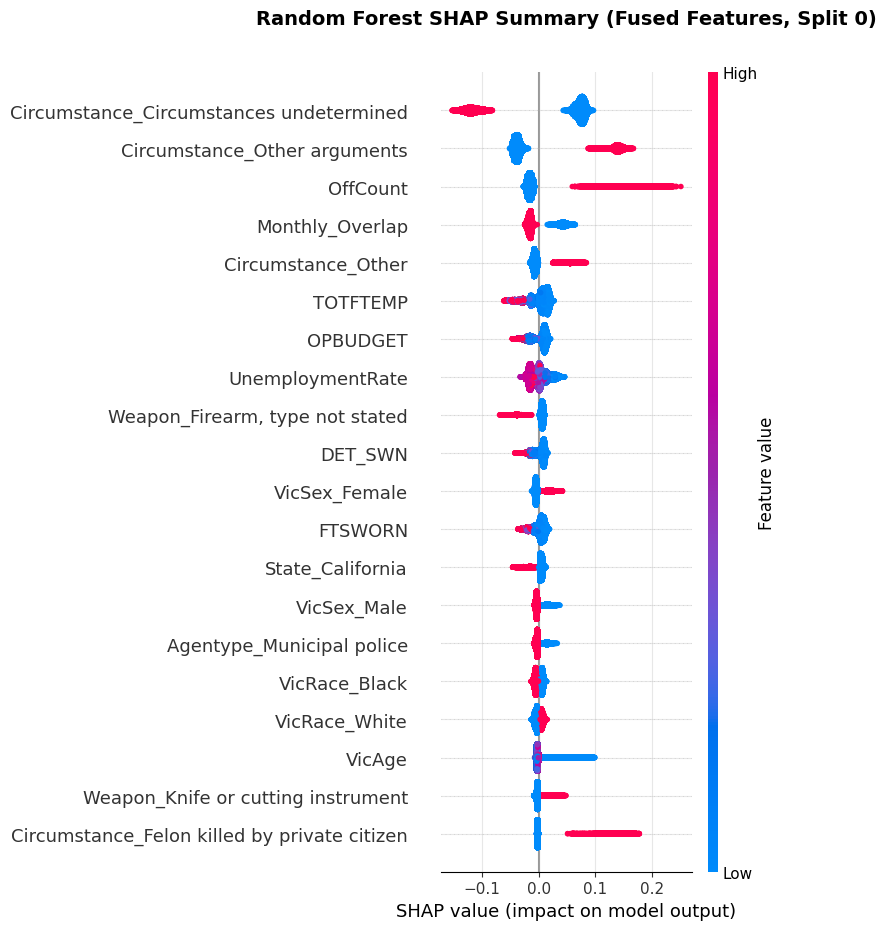

In [48]:
plt.figure(figsize = (10, 10))
shap.summary_plot(plotting_data['rf'], 
                  plotting_data['X_test'], 
                  max_display = 20,
                  show = False)

plt.title("Random Forest SHAP Summary (Fused Features, Split 0)", 
          loc = 'center', 
          y = 1.05
)
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "rf_shap_summary.png"))
plt.show()

In [49]:
import os
print(os.path.abspath(os.path.join(local_dir, "rf_shap_summary.png")))

/Users/mariamkhan/ThesisLocal/rf_shap_summary.png


**XGBoost SHAP Summary Plot**

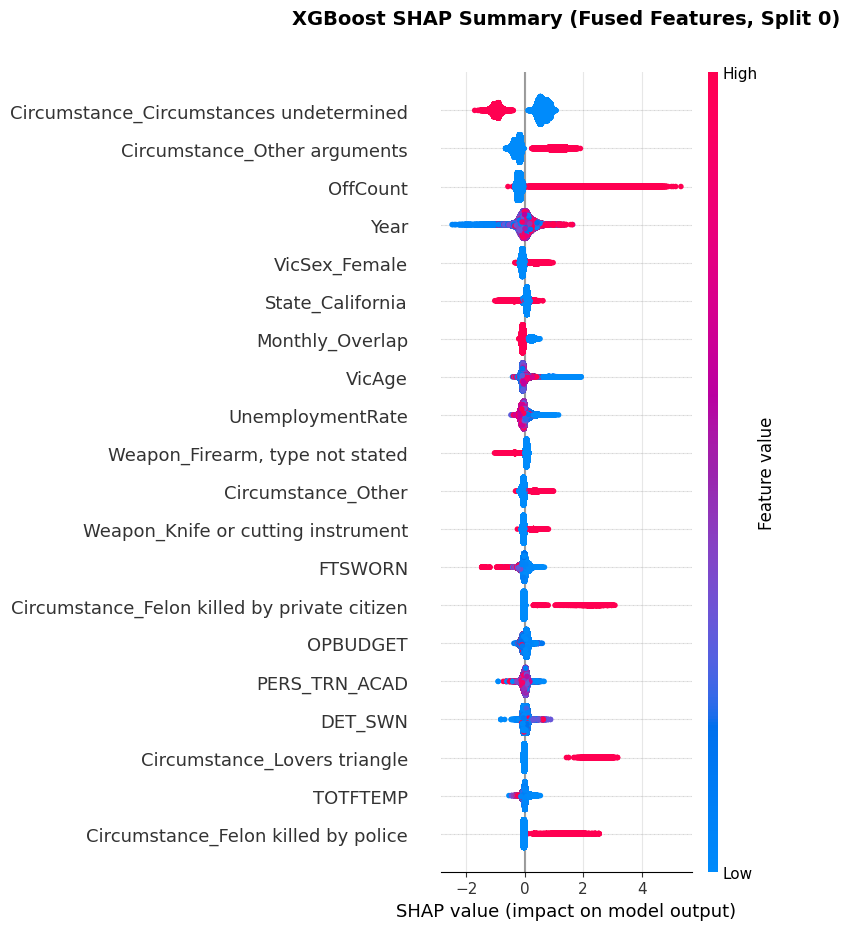

In [50]:
# xgboost shap summary plot
plt.figure(figsize = (10, 10))
shap.summary_plot(plotting_data['xgb'], 
                  plotting_data['X_test'], 
                  max_display = 20,
                  show = False)

plt.title("XGBoost SHAP Summary (Fused Features, Split 0)",
          loc = 'center', 
          y = 1.05
)
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "xgb_shap_summary.png"))
plt.show()

**Random Forest Importance Bar Chart**

In [51]:
rf_importance = pd.DataFrame({
    'Feature': plotting_data['X_test'].columns,
    'Mean_Abs_SHAP': np.mean(np.abs(plotting_data['rf']), axis = 0)
}).sort_values('Mean_Abs_SHAP', ascending = False).reset_index(drop = True)
rf_importance['Rank'] = range(1, len(rf_importance) + 1)

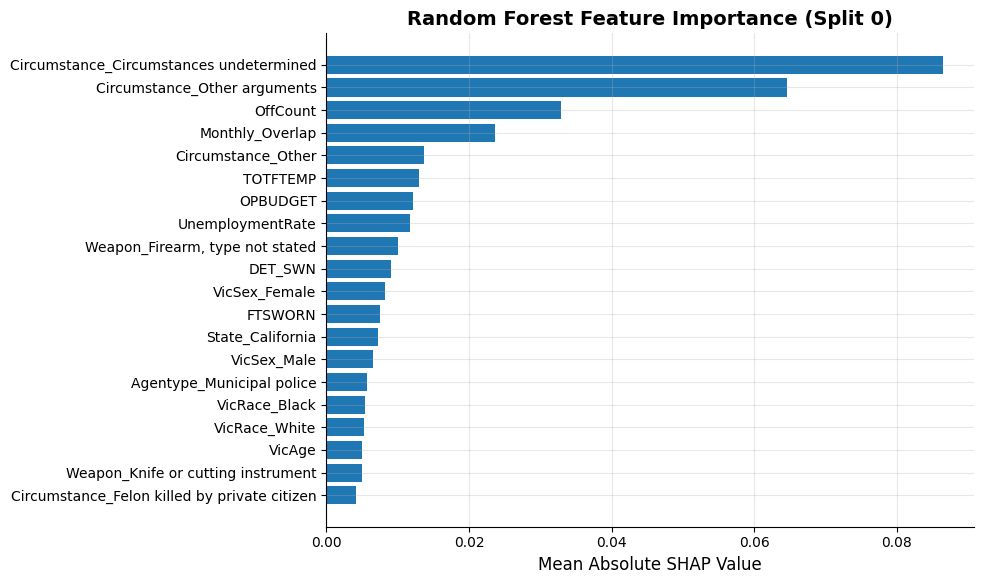

In [52]:
top20_rf = rf_importance.head(20).sort_values('Mean_Abs_SHAP')
fig, ax = plt.subplots(figsize = (10, 6))

ax.barh(
    top20_rf['Feature'], 
    top20_rf['Mean_Abs_SHAP'], 
    color = model_colours['Random Forest']
)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_title("Random Forest Feature Importance (Split 0)")
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "rf_shap_barplot.png"))
plt.show()

**XGBoost Importance Bar Chart**

In [53]:
xgb_importance = pd.DataFrame({
    'Feature': plotting_data['X_test'].columns,
    'Mean_Abs_SHAP': np.mean(np.abs(plotting_data['xgb']), axis = 0)
}).sort_values('Mean_Abs_SHAP', ascending = False).reset_index(drop = True)
xgb_importance['Rank'] = range(1, len(xgb_importance) + 1)

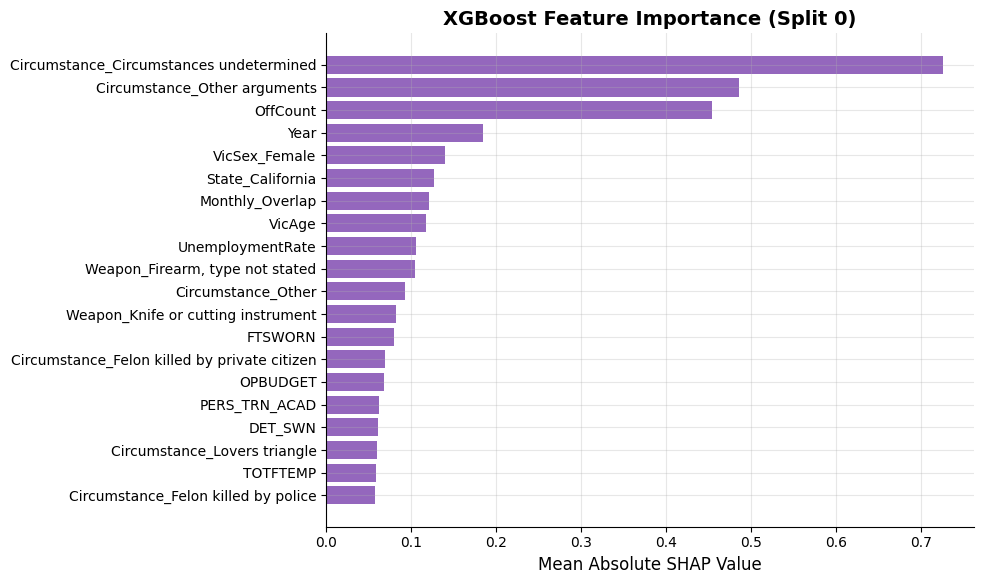

In [54]:
top20_xgb = xgb_importance.head(20).sort_values('Mean_Abs_SHAP')
fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(
    top20_xgb['Feature'], 
    top20_xgb['Mean_Abs_SHAP'], 
    color = model_colours['XGBoost']
)
ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_title("XGBoost Feature Importance (Split 0)")
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "xgb_shap_barplot.png"))
plt.show()

**LEMAS and ACS Feature Importance**

In [55]:
fused_only_features = lemas_acs_cols

print("LEMAS and ACS Feature Ranking - Random Forest (mean +/- std across splits):")
print(
    rank_stability[
        (rank_stability['Model'] == 'Random Forest') & 
        (rank_stability['Feature'].isin(fused_only_features))
        ].to_string(index = False)
)

print("\nLEMAS and ACS Feature Ranking - XGBoost (mean +/- std across splits):")
print(
    rank_stability[
        (rank_stability['Model'] == 'XGBoost') & 
        (rank_stability['Feature'].isin(fused_only_features))
        ].to_string(index = False)
)

LEMAS and ACS Feature Ranking - Random Forest (mean +/- std across splits):
        Model          Feature  mean      std
Random Forest UnemploymentRate   6.5 1.178511
Random Forest         OPBUDGET   6.9 1.100505
Random Forest         TOTFTEMP   7.7 1.059350
Random Forest          DET_SWN  10.2 0.918937
Random Forest          FTSWORN  11.7 0.674949
Random Forest    PERS_TRN_ACAD  23.1 0.567646
Random Forest      PovertyRate  28.2 1.751190
Random Forest   PERS_TRN_INSVC  33.3 1.567021
Random Forest     PERS_EDU_MIN  38.4 0.966092
Random Forest          PTSWORN  42.6 1.173788

LEMAS and ACS Feature Ranking - XGBoost (mean +/- std across splits):
  Model          Feature  mean      std
XGBoost UnemploymentRate   9.0 0.942809
XGBoost          FTSWORN  16.4 5.168279
XGBoost    PERS_TRN_ACAD  16.9 3.071373
XGBoost         OPBUDGET  18.1 5.782156
XGBoost          DET_SWN  18.7 2.710064
XGBoost         TOTFTEMP  19.4 4.299871
XGBoost      PovertyRate  20.1 3.842742
XGBoost   PERS_TRN_INSVC  2

### 9. Subgroup Fairness Analysis

Evaluate the false negative rate, false positive rate, and accuracy across different subgroups to see whether the models are fair across different groups. The analysis focuses on Random Forest and XGBoost because they are the best performing models. Uses split 0 as a representative example, consistent with the SHAP analysis. 

#### 9.1 Fit Models and Combine Predictions with Demographic Data

Predictions come from split 0's fused Random Forest (depth 10, matching the SHAP models)
and XGBoost. Demographic columns (VicRace, VicSex, VicAgeBand) were excluded from the
training features, so they are pulled back in from fused_df using split 0's test indices.

In [56]:
meta0 = split_metadata[0]
imputed_df0 = impute_split(meta0['train_idx'], fused_df)
sd0 = encode_and_scale_split(imputed_df0, meta0['train_idx'], meta0['test_idx'])

rf_fairness = RandomForestClassifier(
    class_weight = meta0['class_weight_dict'],
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1
)

rf_fairness.fit(sd0['X_fused_train'], sd0['y_train'])

xgb_fairness = XGBClassifier(
    scale_pos_weight = meta0['scale_pos_weight'],
    random_state = 42,
    n_jobs = -1,
    eval_metric = 'logloss'
)

xgb_fairness.fit(sd0['X_fused_train'], sd0['y_train'])

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [57]:
# get predictions from both models for the test set
y_pred_rf = rf_fairness.predict(sd0['X_fused_test'])
y_pred_xgb = xgb_fairness.predict(sd0['X_fused_test'])

fairness_df = fused_df.loc[
    meta0['test_idx'],
    ['VicRace', 'VicSex', 'VicAgeBand']
].copy()

fairness_df['y_true'] = sd0['y_test'].values # true labels
fairness_df['y_pred_rf'] = y_pred_rf # predictions from random forest
fairness_df['y_pred_xgb'] = y_pred_xgb # predictions from xgboost

print(f"Fairness DataFrame Shape: {fairness_df.shape}\n")

# check the solved rate in the fairness dataframe 
# should be the same as the solved rate in the test set
print("Solved Rate in fairness_df: "
      f"{fairness_df['y_true'].mean():.2%}")

Fairness DataFrame Shape: (175642, 6)

Solved Rate in fairness_df: 70.60%


#### 9.2 Subgroup Fairness Metrics

False negative rate (FNR) measures the proportion of solved cases the model predicted as unsolved but were actually solved. It realtes directly to the discretionary perspective framing.

`FNR = False Negatives / (False Negatives + True Positives)`



In [58]:
def compute_subgroup_metrics(df, group_col, pred_col):
    results = []
    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        y_true_sub = subset['y_true']
        y_pred_sub = subset[pred_col]

        # confusion matrix components
        tp = ((y_true_sub == 1) & (y_pred_sub == 1)).sum()
        fn = ((y_true_sub == 1) & (y_pred_sub == 0)).sum()
        fp = ((y_true_sub == 0) & (y_pred_sub == 1)).sum()
        tn = ((y_true_sub == 0) & (y_pred_sub == 0)).sum()

        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        accuracy = (tp + tn) / len(subset)

        results.append({
            'Group': group,
            'Count': len(subset),
            'FNR': fnr,
            'FPR': fpr,
            'Accuracy': accuracy
        })

    return pd.DataFrame(results).sort_values('Count', ascending = False).reset_index(drop = True)

#### 9.3 FNR by Subgroup

**Victim Sex**

In [59]:
print("Subgroup Metrics by Victim Sex - Random Forest:")
sex_metrics_rf = compute_subgroup_metrics(fairness_df, 'VicSex', 'y_pred_rf')
print(sex_metrics_rf.to_string(index = False))

print("\nSubgroup Metrics by Victim Sex - XGBoost:")
sex_metrics_xgb = compute_subgroup_metrics(fairness_df, 'VicSex', 'y_pred_xgb')
print(sex_metrics_xgb.to_string(index = False))

Subgroup Metrics by Victim Sex - Random Forest:
  Group  Count      FNR      FPR  Accuracy
   Male 136460 0.243972 0.188469  0.773523
 Female  39060 0.175419 0.277966  0.802074
Unknown    122 0.230769 0.368421  0.704918

Subgroup Metrics by Victim Sex - XGBoost:
  Group  Count      FNR      FPR  Accuracy
   Male 136460 0.238932 0.142508  0.791463
 Female  39060 0.159150 0.216144  0.828341
Unknown    122 0.323077 0.175439  0.745902


**Victim Race**

In [60]:
print("Subgroup Metrics by Victim Race - Random Forest:")
race_metrics_rf = compute_subgroup_metrics(fairness_df, 'VicRace', 'y_pred_rf')
print(race_metrics_rf.to_string(index = False)) 

print("\nSubgroup Metrics by Victim Race - XGBoost:")
race_metrics_xgb = compute_subgroup_metrics(fairness_df, 'VicRace', 'y_pred_xgb')
print(race_metrics_xgb.to_string(index = False))

Subgroup Metrics by Victim Race - Random Forest:
                              Group  Count      FNR      FPR  Accuracy
                              Black  85290 0.278512 0.158421  0.762071
                              White  84764 0.182595 0.262187  0.797449
                              Asian   2475 0.205618 0.241727  0.784242
                            Unknown   1688 0.262489 0.247019  0.742891
  American Indian or Alaskan Native   1375 0.158614 0.205036  0.832000
Native Hawaiian or Pacific Islander     50 0.205128 0.272727  0.780000

Subgroup Metrics by Victim Race - XGBoost:
                              Group  Count      FNR      FPR  Accuracy
                              Black  85290 0.264893 0.123864  0.782765
                              White  84764 0.179982 0.196029  0.815995
                              Asian   2475 0.207865 0.143885  0.810101
                            Unknown   1688 0.244323 0.177172  0.779028
  American Indian or Alaskan Native   1375 0.150410 0.1

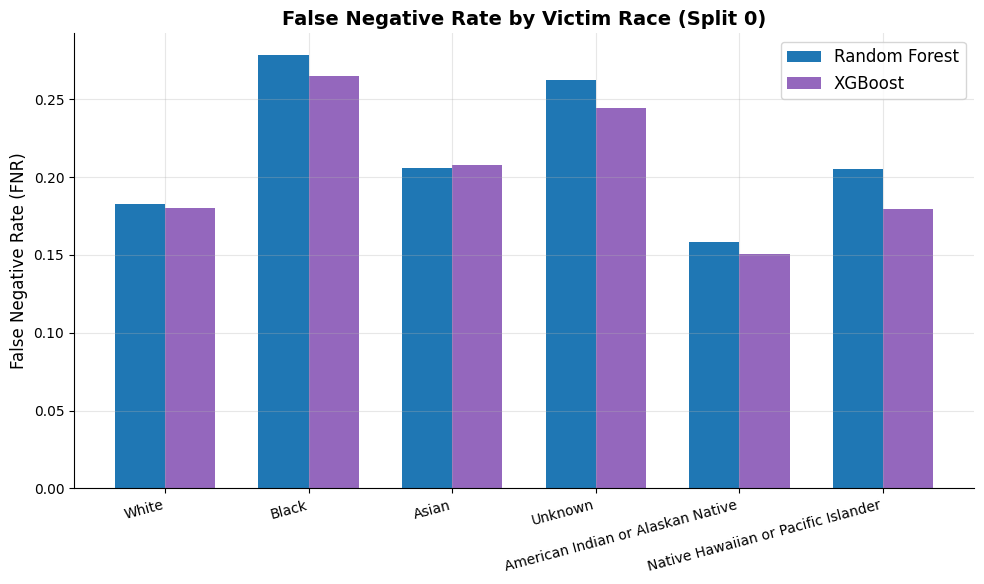

In [67]:
main_groups = ['White', 'Black', 'Asian', 'Unknown',
               'American Indian or Alaskan Native',
               'Native Hawaiian or Pacific Islander']

race_rf_plot = race_metrics_rf.set_index('Group').loc[main_groups]
race_xgb_plot = race_metrics_xgb.set_index('Group').loc[main_groups]

fig, ax = plt.subplots(figsize = (10, 6))
x = np.arange(len(main_groups))
width = 0.35

ax.bar(
    x - width/2,
    race_rf_plot['FNR'],
    width,
    label = 'Random Forest',
    color = model_colours['Random Forest']
)

ax.bar(
    x + width/2,
    race_xgb_plot['FNR'],
    width,
    label = 'XGBoost',
    color = model_colours['XGBoost']
)

ax.set_ylabel('False Negative Rate (FNR)')
ax.set_title('False Negative Rate by Victim Race (Split 0)')
ax.set_xticks(x)
ax.set_xticklabels(main_groups, rotation = 15, ha = 'right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "ofnr_by_race.png"))
plt.show()

**Victim Age Band**

In [62]:
age_order = ['0 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24',
             '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', 
             '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74', 
             '75 - 79', '80 - 84', '85 - 89', '90 - 94', '95 - 99']

age_metrics_rf = compute_subgroup_metrics(
    fairness_df, 'VicAgeBand', 'y_pred_rf'
    ).set_index('Group').loc[age_order]

age_metrics_xgb = compute_subgroup_metrics(
    fairness_df, 'VicAgeBand', 'y_pred_xgb'
    ).set_index('Group').loc[age_order]

print("Subgroup Metrics by Victim Age Band - Random Forest:")
print(age_metrics_rf.to_string())

print("\nSubgroup Metrics by Victim Age Band - XGBoost:")
print(age_metrics_xgb.to_string())

Subgroup Metrics by Victim Age Band - Random Forest:
         Count       FNR       FPR  Accuracy
Group                                       
0 - 4     5378  0.095308  0.602058  0.849758
5 - 9     1293  0.135111  0.422619  0.827533
10 - 14   2076  0.250605  0.261792  0.747110
15 - 19  18645  0.289201  0.170565  0.748887
20 - 24  30721  0.253373  0.182532  0.770125
25 - 29  27441  0.238811  0.188303  0.777523
30 - 34  22386  0.222388  0.187831  0.788395
35 - 39  17316  0.206687  0.193471  0.797124
40 - 44  13523  0.210418  0.197098  0.793315
45 - 49  10045  0.209726  0.213567  0.789248
50 - 54   7712  0.202518  0.236209  0.788771
55 - 59   5874  0.216937  0.236573  0.777835
60 - 64   4277  0.213543  0.247731  0.777648
65 - 69   3076  0.218237  0.286089  0.764954
70 - 74   2136  0.221374  0.304965  0.756554
75 - 79   1656  0.232143  0.325472  0.743961
80 - 84   1110  0.257353  0.333333  0.722523
85 - 89    625  0.224622  0.327160  0.748800
90 - 94    252  0.186170  0.359375  0.769841
95

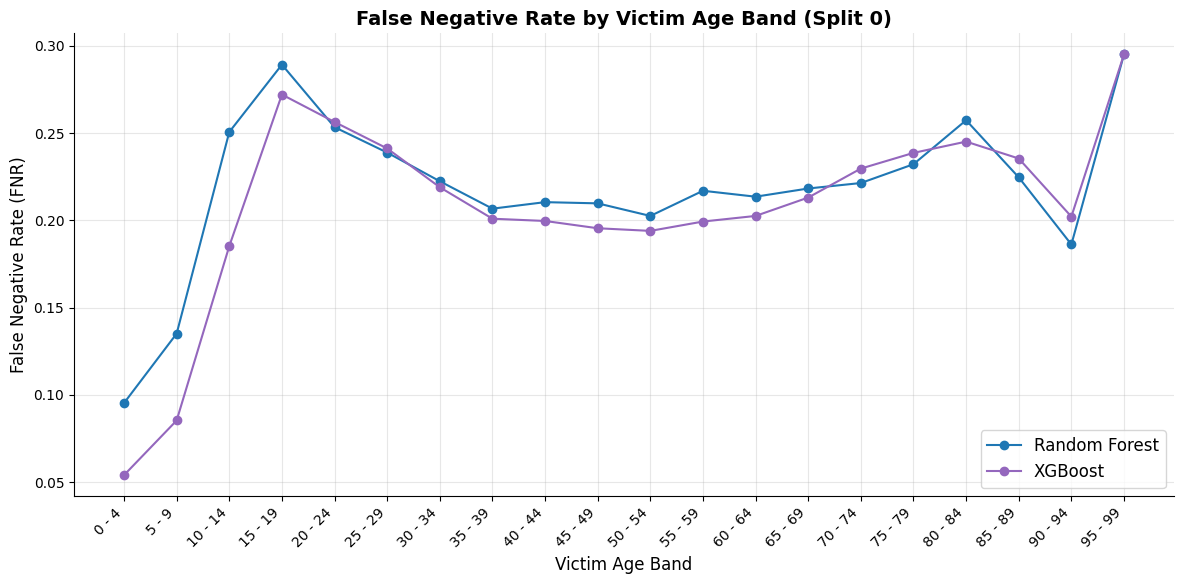

In [64]:
fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(
    age_order, 
    age_metrics_rf['FNR'], 
    marker = 'o', 
    label = 'Random Forest', 
    color = model_colours['Random Forest'])

ax.plot(
    age_order, 
    age_metrics_xgb['FNR'], 
    marker = 'o', 
    label = 'XGBoost', 
    color = model_colours['XGBoost'])

ax.set_xlabel("Victim Age Band")
ax.set_ylabel("False Negative Rate (FNR)")
ax.set_title("False Negative Rate by Victim Age Band (Split 0)")
ax.set_xticks(age_order)
ax.set_xticklabels(age_order, rotation = 45, ha = 'right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(local_dir, "fnr_by_age_band.png"))
plt.show()

### 10. Final Checks

#### 10.1 NearLemas Sensitivity Analysis

NearLemas flags cases from 2018 to 2022, close to when the LEMAS survey was conducted. This analysis checks whether the model's performance is affected by the presence of NearLemas cases in the test set.

In [65]:
fairness_df['NearLemas'] = fused_df.loc[meta0['test_idx'], 'NearLemas'].values

print("\nSubgroup Metrics by NearLemas - Random Forest:")
print(
    compute_subgroup_metrics(
        fairness_df, 
        'NearLemas', 
        'y_pred_rf'
    ).to_string(index = False)
)

print("\nSubgroup Metrics by NearLemas - XGBoost:")
print(
    compute_subgroup_metrics(
        fairness_df, 
        'NearLemas', 
        'y_pred_xgb'
    ).to_string(index = False)
)



Subgroup Metrics by NearLemas - Random Forest:
 Group  Count      FNR      FPR  Accuracy
     0 156512 0.216989 0.205791  0.786285
     1  19130 0.311740 0.185896  0.726973

Subgroup Metrics by NearLemas - XGBoost:
 Group  Count      FNR      FPR  Accuracy
     0 156512 0.214073 0.153540  0.803625
     1  19130 0.263571 0.164316  0.766963


#### 10.2 Depth 10 vs Depth 25 Feature Agreement

The depth 10 model is used for SHAP because the depth 25 model takes too long to compute SHAP values. This analysis checks whether the two models agree on which features are most important in predicting case clearance.


In [66]:
imputed_df0 = impute_split(meta0['train_idx'], fused_df)
sd0 = encode_and_scale_split(imputed_df0, meta0['train_idx'], meta0['test_idx'])

rf_fused_deep = RandomForestClassifier(
    class_weight = meta0['class_weight_dict'],
    n_estimators = 100,
    max_depth = 25,
    random_state = 42,
    n_jobs = -1
)
rf_fused_deep.fit(sd0['X_fused_train'], sd0['y_train'])

depth25_importance = (
    pd.DataFrame({
        'Feature': sd0['X_fused_test'].columns,
        'Importance_Depth25': rf_fused_deep.feature_importances_
    })
    .sort_values('Importance_Depth25', ascending = False)
    .reset_index(drop = True)
)

depth25_importance['Rank_Depth25'] = (range(1, len(depth25_importance) + 1))

depth10_ranks = rf_importance[['Feature', 'Rank']].rename(columns = {'Rank': 'Rank_Depth10'})

comparison = depth25_importance[['Feature', 'Rank_Depth25']].merge(depth10_ranks, on = 'Feature')
comparison['Rank_Diff'] = (comparison['Rank_Depth25'] - comparison['Rank_Depth10']).abs()

corr, p_value = spearmanr(comparison['Rank_Depth25'], comparison['Rank_Depth10'])

print(
    f"Spearman Rank Correlation between Depth 25 "
    f"and Depth 10 Feature Importance Ranks: {corr:.3f} "
    f"(p-value = {p_value:.6f})"
)

print(
    f"\nTop 15 Features by Depth 25 Importance " \
    f"with their Rank Differences:"     
)

print(comparison.sort_values('Rank_Depth25').head(15).to_string(index = False))   

Spearman Rank Correlation between Depth 25 and Depth 10 Feature Importance Ranks: 0.910 (p-value = 0.000000)

Top 15 Features by Depth 25 Importance with their Rank Differences:
                                Feature  Rank_Depth25  Rank_Depth10  Rank_Diff
Circumstance_Circumstances undetermined             1             1          0
           Circumstance_Other arguments             2             2          0
                               OffCount             3             3          0
                                   Year             4            21         17
                                 VicAge             5            18         13
                       UnemploymentRate             6             8          2
                     Circumstance_Other             7             5          2
                               OPBUDGET             8             7          1
                               TOTFTEMP             9             6          3
                                